# Tech Challenge - CNN com Mamografias

Este notebook implementa a parte de visão computacional do desafio. Ele usa imagens locais do CBIS-DDSM em `cnn_data/` para classificar achados como malignos ou benignos a partir de imagens recortadas.

## 0. Ambiente virtual e dependências

Execute esta célula primeiro. Ela cria o venv do notebook, instala o `requirements.txt` correspondente e registra o kernel Jupyter. Se o notebook não estiver usando esse venv, a célula vai pedir para trocar o kernel antes de continuar.


In [1]:
from pathlib import Path
import hashlib
import os
import subprocess
import sys

def find_project_root_for_setup(start: Path | None = None) -> Path:
    """Locate the project root so setup works from any notebook folder."""
    current = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'breast_cancer_wisconsin.csv').is_file() and (candidate / 'cnn_data').is_dir():
            return candidate
    raise FileNotFoundError('Project root not found. Keep breast_cancer_wisconsin.csv and cnn_data/ at the root.')

PROJECT_ROOT_SETUP = find_project_root_for_setup()
VENV_DIR = PROJECT_ROOT_SETUP / '.venv-cnn'
REQUIREMENTS_FILE = PROJECT_ROOT_SETUP / 'notebooks/cnn/requirements.txt'
KERNEL_NAME = 'tech-challenge-cnn'
KERNEL_DISPLAY_NAME = 'Tech Challenge CNN'

def venv_python_path(venv_dir: Path) -> Path:
    """Return the Python executable path for Linux/macOS or Windows."""
    if os.name == 'nt':
        return venv_dir / 'Scripts' / 'python.exe'
    return venv_dir / 'bin' / 'python'

VENV_PYTHON = venv_python_path(VENV_DIR)
if not VENV_PYTHON.exists():
    print(f'Creating virtual environment: {VENV_DIR.relative_to(PROJECT_ROOT_SETUP)}')
    subprocess.check_call([sys.executable, '-m', 'venv', str(VENV_DIR)])
else:
    print(f'Virtual environment already exists: {VENV_DIR.relative_to(PROJECT_ROOT_SETUP)}')

requirements_hash = hashlib.sha256(REQUIREMENTS_FILE.read_bytes()).hexdigest()
marker_file = VENV_DIR / f'.requirements-{requirements_hash}.installed'

if marker_file.exists():
    print('Requirements already installed for the current requirements.txt hash.')
else:
    print(f'Installing requirements from: {REQUIREMENTS_FILE.relative_to(PROJECT_ROOT_SETUP)}')
    subprocess.check_call([str(VENV_PYTHON), '-m', 'pip', 'install', '--upgrade', 'pip'])
    subprocess.check_call([str(VENV_PYTHON), '-m', 'pip', 'install', '-r', str(REQUIREMENTS_FILE)])

    for old_marker in VENV_DIR.glob('.requirements-*.installed'):
        old_marker.unlink(missing_ok=True)
    marker_file.write_text('ok\n', encoding='utf-8')

subprocess.check_call([
    str(VENV_PYTHON),
    '-m',
    'ipykernel',
    'install',
    '--user',
    '--name',
    KERNEL_NAME,
    '--display-name',
    KERNEL_DISPLAY_NAME,
])

running_in_target_venv = Path(sys.prefix).resolve() == VENV_DIR.resolve()
print(f'Target venv: {VENV_DIR}')
print(f'Current Python prefix: {sys.prefix}')

if not running_in_target_venv:
    raise SystemExit(
        f'Environment prepared. Now switch the notebook kernel to "{KERNEL_DISPLAY_NAME}" '
        'and run the notebook again from the beginning.'
    )

print('Notebook is running inside the expected virtual environment.')


Virtual environment already exists: .venv-cnn
Requirements already installed for the current requirements.txt hash.
Installed kernelspec tech-challenge-cnn in /Users/camila/Library/Jupyter/kernels/tech-challenge-cnn
Target venv: /Users/camila/Documents/Documentos - MacBook Pro de Camila/FIAP - IA para DEVS/tech_challenge_a/.venv-cnn
Current Python prefix: /Users/camila/Documents/Documentos - MacBook Pro de Camila/FIAP - IA para DEVS/tech_challenge_a/.venv-cnn
Notebook is running inside the expected virtual environment.


## 1. Configuração portátil e foco em CPU

O notebook evita caminhos absolutos, usa `pathlib.Path` e procura a raiz do projeto automaticamente. A execução padrão é leve para CPU local.

In [2]:
from pathlib import Path
import os
import tempfile
import warnings

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

os.environ.setdefault('CUDA_VISIBLE_DEVICES', '-1')
os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'matplotlib-tech-challenge'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from PIL import Image
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings('ignore')
%matplotlib inline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

FORCE_CPU = True
if FORCE_CPU:
    try:
        tf.config.set_visible_devices([], 'GPU')
    except RuntimeError as exc:
        print(f'GPU já inicializada antes do ajuste: {exc}')

print(f'TensorFlow: {tf.__version__}')


Matplotlib is building the font cache; this may take a moment.


TensorFlow: 2.16.2


In [3]:
def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root from any notebook working directory."""
    current = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'cnn_data').is_dir() and (candidate / 'breast_cancer_wisconsin.csv').is_file():
            return candidate
    raise FileNotFoundError('Project root not found. Keep cnn_data/ and breast_cancer_wisconsin.csv at the root.')

PROJECT_ROOT = find_project_root()
CNN_DIR = PROJECT_ROOT / 'cnn_data'
CSV_DIR = CNN_DIR / 'csv'
JPEG_DIR = CNN_DIR / 'jpeg'
REPORTS_DIR = PROJECT_ROOT / 'reports'
REPORTS_DIR.mkdir(exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'CSV dir: {CSV_DIR.relative_to(PROJECT_ROOT)}')
print(f'JPEG dir: {JPEG_DIR.relative_to(PROJECT_ROOT)}')

Project root: /Users/camila/Documents/Documentos - MacBook Pro de Camila/FIAP - IA para DEVS/tech_challenge_a
CSV dir: cnn_data/csv
JPEG dir: cnn_data/jpeg


## 2. Parâmetros de desempenho

O modo rápido usa uma amostra balanceada para permitir execução em CPU. Para treinar com mais dados, aumente os limites ou defina `QUICK_MODE = False`.

In [4]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 16
EPOCHS = 12
QUICK_MODE = True

MAX_TRAIN_PER_CLASS = 900
MAX_VAL_PER_CLASS = 220
MAX_TEST_PER_CLASS = 276

print('Configuração da CNN')
print(f'Imagem: {IMG_SIZE} | Batch: {BATCH_SIZE} | Epocas maximas: {EPOCHS} | Quick mode: {QUICK_MODE}')


Configuração da CNN
Imagem: (128, 128) | Batch: 16 | Epocas maximas: 12 | Quick mode: True


## 3. Carregamento dos metadados

Os CSVs de massa e calcificação possuem o rótulo `pathology`. O arquivo `dicom_info.csv` faz a ponte entre o identificador do exame e o JPG local.

In [5]:
CASE_FILES = [
    ('train', 'mass', CSV_DIR / 'mass_case_description_train_set.csv'),
    ('test', 'mass', CSV_DIR / 'mass_case_description_test_set.csv'),
    ('train', 'calcification', CSV_DIR / 'calc_case_description_train_set.csv'),
    ('test', 'calcification', CSV_DIR / 'calc_case_description_test_set.csv'),
]

def load_case_file(split: str, lesion_type: str, path: Path) -> pd.DataFrame:
    """Load one metadata file and standardize columns used later."""
    frame = pd.read_csv(path)
    frame.columns = frame.columns.str.strip().str.replace('breast density', 'breast_density', regex=False)
    frame['split'] = split
    frame['lesion_type'] = lesion_type
    frame['source_file'] = path.name
    return frame

case_frames = [load_case_file(split, lesion_type, path) for split, lesion_type, path in CASE_FILES]
cases = pd.concat(case_frames, ignore_index=True)

cases['pathology'] = cases['pathology'].astype(str).str.strip().str.upper()
valid_labels = ['BENIGN', 'BENIGN_WITHOUT_CALLBACK', 'MALIGNANT']
cases = cases[cases['pathology'].isin(valid_labels)].copy()
cases['target'] = cases['pathology'].eq('MALIGNANT').astype(int)

display(cases[['split', 'lesion_type', 'pathology', 'target']].head())
display(pd.crosstab([cases['split'], cases['lesion_type']], cases['pathology']))

,split,lesion_type,pathology,target
0,train,mass,MALIGNANT,1
1,train,mass,MALIGNANT,1
2,train,mass,BENIGN,0
3,train,mass,BENIGN,0
4,train,mass,BENIGN,0


pathology            BENIGN  BENIGN_WITHOUT_CALLBACK  MALIGNANT
split lesion_type                                              
test  calcification     130                       67        129
      mass              194                       37        147
train calcification     528                      474        544
      mass              577                      104        637

In [6]:
def extract_patient_image_id(value: object) -> str | None:
    """Extract the first path component used as PatientID in dicom_info.csv."""
    if pd.isna(value):
        return None
    cleaned = str(value).replace('\\n', '').strip()
    return cleaned.split('/')[0] if cleaned else None

dicom_info = pd.read_csv(
    CSV_DIR / 'dicom_info.csv',
    usecols=['PatientID', 'SeriesDescription', 'image_path'],
)

cropped_lookup = (
    dicom_info[dicom_info['SeriesDescription'].eq('cropped images')]
    .dropna(subset=['PatientID', 'image_path'])
    .drop_duplicates(subset=['PatientID'])
)

cases['patient_image_id'] = cases['cropped image file path'].map(extract_patient_image_id)
image_df = cases.merge(
    cropped_lookup[['PatientID', 'image_path']],
    left_on='patient_image_id',
    right_on='PatientID',
    how='left',
)

image_df['relative_jpg'] = image_df['image_path'].astype(str).str.replace('CBIS-DDSM/jpeg/', 'cnn_data/jpeg/', regex=False)
image_df['image_path_local'] = image_df['relative_jpg'].map(lambda p: PROJECT_ROOT / p)

image_df['file_exists'] = image_df['image_path_local'].map(lambda p: p.is_file() and ':Zone.Identifier' not in str(p))
image_df = image_df[image_df['file_exists']].copy()

print(f'Casos com imagem local encontrada: {len(image_df)}')
display(pd.crosstab(image_df['split'], image_df['target'], rownames=['split'], colnames=['target 0=benigno 1=maligno']))
display(image_df[['split', 'lesion_type', 'pathology', 'relative_jpg']].head())

Casos com imagem local encontrada: 3567


target 0=benigno 1=maligno,0,1
split,,
test,428,276
train,1682,1181


,split,lesion_type,pathology,relative_jpg
0,train,mass,MALIGNANT,cnn_data/jpeg/1.3.6.1.4.1.9590.100.1.2.2967364...
1,train,mass,MALIGNANT,cnn_data/jpeg/1.3.6.1.4.1.9590.100.1.2.2279552...
2,train,mass,BENIGN,cnn_data/jpeg/1.3.6.1.4.1.9590.100.1.2.4291204...
3,train,mass,BENIGN,cnn_data/jpeg/1.3.6.1.4.1.9590.100.1.2.1151342...
4,train,mass,BENIGN,cnn_data/jpeg/1.3.6.1.4.1.9590.100.1.2.1285736...


## 4. Separação treino, validação e teste

Os arquivos originais já separam treino e teste. A validação é retirada apenas do treino para evitar vazamento de dados.

In [7]:
train_full_df = image_df[image_df['split'].eq('train')].reset_index(drop=True)
test_df = image_df[image_df['split'].eq('test')].reset_index(drop=True)

train_df, val_df = train_test_split(
    train_full_df,
    test_size=0.2,
    stratify=train_full_df['target'],
    random_state=RANDOM_STATE,
)

def balanced_sample(frame: pd.DataFrame, max_per_class: int) -> pd.DataFrame:
    """Keep class balance and limit runtime in CPU mode."""
    sampled = []
    for label, part in frame.groupby('target'):
        n = min(len(part), max_per_class)
        sampled.append(part.sample(n=n, random_state=RANDOM_STATE))
    return pd.concat(sampled).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

if QUICK_MODE:
    train_df = balanced_sample(train_df, MAX_TRAIN_PER_CLASS)
    val_df = balanced_sample(val_df, MAX_VAL_PER_CLASS)
    test_df = balanced_sample(test_df, MAX_TEST_PER_CLASS)

print(f'Treino: {len(train_df)} | Validacao: {len(val_df)} | Teste: {len(test_df)}')
display(pd.DataFrame({
    'treino': train_df['target'].value_counts().sort_index(),
    'validação': val_df['target'].value_counts().sort_index(),
    'teste': test_df['target'].value_counts().sort_index(),
}).rename(index={0: 'Benigno', 1: 'Maligno'}))

Treino: 1800 | Validacao: 440 | Teste: 552


,treino,validação,teste
target,,,
Benigno,900,220,276
Maligno,900,220,276


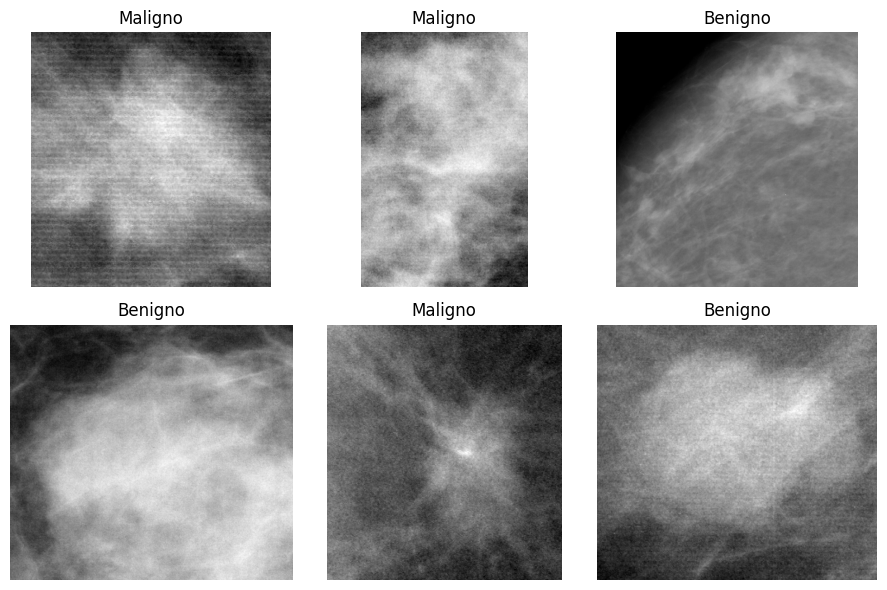

In [8]:
sample_images = train_df.groupby('target', group_keys=False).head(3)
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for ax, row in zip(axes.ravel(), sample_images.itertuples(index=False)):
    image = Image.open(row.image_path_local).convert('L')
    ax.imshow(image, cmap='gray')
    ax.set_title('Maligno' if row.target == 1 else 'Benigno')
    ax.axis('off')
for ax in axes.ravel()[len(sample_images):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'cnn_sample_images.png', dpi=160, bbox_inches='tight')
plt.show()

## 5. Pipeline de imagens com TensorFlow

As imagens são lidas sob demanda, redimensionadas para `128x128` e normalizadas para o intervalo `[0, 1]`.

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

@tf.autograph.experimental.do_not_convert
def load_image(path: tf.Tensor, label: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    """Read a JPEG image, resize it and normalize contrast per image."""
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image_bytes, channels=1)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    image = tf.image.per_image_standardization(image)
    return image, tf.cast(label, tf.float32)

def make_dataset(frame: pd.DataFrame, shuffle: bool) -> tf.data.Dataset:
    paths = frame['image_path_local'].astype(str).to_numpy()
    labels = frame['target'].astype('float32').to_numpy()
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(frame), seed=RANDOM_STATE, reshuffle_each_iteration=True)
    return dataset.map(load_image, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_df['target'].to_numpy(),
)
class_weight = {0: float(class_weights_array[0]), 1: float(class_weights_array[1])}
print(f'Class weights: {class_weight}')


Class weights: {0: 1.0, 1: 1.0}


## 6. Modelo CNN

A arquitetura é intencionalmente simples para ser didática e viável em CPU. `Dropout` ajuda a reduzir overfitting em uma base relativamente pequena.

In [10]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.03),
        layers.RandomZoom(0.05),
    ],
    name='data_augmentation',
)

def conv_block(x: tf.Tensor, filters: int, dropout_rate: float) -> tf.Tensor:
    """Small convolutional block with normalization to stabilize CPU training."""
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    return x

def build_cnn_model() -> keras.Model:
    inputs = keras.Input(shape=(*IMG_SIZE, 1), name='mammography_crop')
    x = data_augmentation(inputs)
    x = conv_block(x, filters=32, dropout_rate=0.10)
    x = conv_block(x, filters=64, dropout_rate=0.15)
    x = conv_block(x, filters=128, dropout_rate=0.20)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(96, activation='relu')(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(1, activation='sigmoid', name='malignant_probability')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-4),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.BinaryAccuracy(name='accuracy'),
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ],
    )
    return model

model = build_cnn_model()
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mammography_crop (InputLayer)   │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 300,257 (1.15 MB)

 Trainable params: 299,361 (1.14 MB)

 Non-trainable params: 896 (3.50 KB)

In [11]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=4,
    restore_best_weights=True,
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    mode='max',
    factor=0.5,
    patience=2,
    min_lr=1e-5,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=[early_stopping, reduce_lr],
)


Epoch 1/12
113/113 ━━━━━━━━━━━━━━━━━━━━ 33s 276ms/step - accuracy: 0.5683 - auc: 0.5805 - loss: 0.6882 - precision: 0.5604 - recall: 0.6344 - val_accuracy: 0.5318 - val_auc: 0.5684 - val_loss: 0.6906 - val_precision: 0.5188 - val_recall: 0.8773 - learning_rate: 5.0000e-04
Epoch 2/12
113/113 ━━━━━━━━━━━━━━━━━━━━ 31s 274ms/step - accuracy: 0.5661 - auc: 0.5823 - loss: 0.6750 - precision: 0.5549 - recall: 0.6678 - val_accuracy: 0.5250 - val_auc: 0.5887 - val_loss: 0.6806 - val_precision: 0.5733 - val_recall: 0.1955 - learning_rate: 5.0000e-04
Epoch 3/12
113/113 ━━━━━━━━━━━━━━━━━━━━ 28s 245ms/step - accuracy: 0.5794 - auc: 0.6091 - loss: 0.6629 - precision: 0.5665 - recall: 0.6767 - val_accuracy: 0.5364 - val_auc: 0.5996 - val_loss: 0.6697 - val_precision: 0.5367 - val_recall: 0.5318 - learning_rate: 5.0000e-04
Epoch 4/12
113/113 ━━━━━━━━━━━━━━━━━━━━ 29s 258ms/step - accuracy: 0.5694 - auc: 0.6005 - loss: 0.6669 - precision: 0.5539 - recall: 0.7133 - val_accuracy: 0.5364 - val_auc: 0.6389 

## 7. Avaliação

Assim como no modelo tabular, recall para maligno é uma métrica central porque falsos negativos podem atrasar investigação clínica.

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
7,0.575556,0.597195,0.670196,0.559649,0.708889,0.604545,0.660248,0.653600,0.607477,0.590909,0.00050
8,0.579444,0.605852,0.664560,0.557246,0.773333,0.604545,0.650393,0.656644,0.623656,0.527273,0.00050
9,0.562222,0.605334,0.659903,0.547782,0.713333,0.588636,0.656983,0.648500,0.581590,0.631818,0.00050
10,0.603333,0.641941,0.646465,0.577243,0.772222,0.625000,0.673450,0.644778,0.608696,0.700000,0.00025
11,0.596111,0.643252,0.650130,0.568705,0.795556,0.565909,0.675041,0.667742,0.693333,0.236364,0.00025


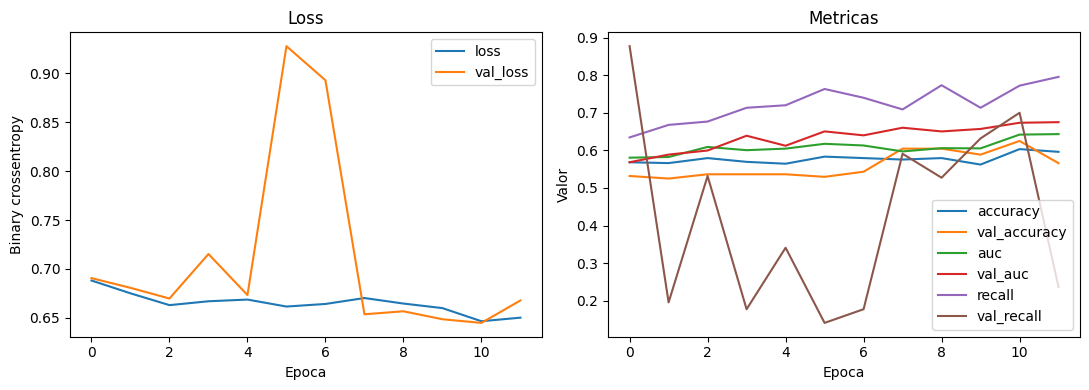

In [12]:
history_df = pd.DataFrame(history.history)
display(history_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
history_df[['loss', 'val_loss']].plot(ax=axes[0])
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Binary crossentropy')

metric_columns = [column for column in ['accuracy', 'val_accuracy', 'auc', 'val_auc', 'recall', 'val_recall'] if column in history_df]
history_df[metric_columns].plot(ax=axes[1])
axes[1].set_title('Metricas')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Valor')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'cnn_training_curves.png', dpi=160, bbox_inches='tight')
plt.show()


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step
Melhor threshold pela validação: 0.20


,threshold,f1_maligno,balanced_accuracy,predicted_positive_rate
10,0.20,0.706868,0.602273,0.856818
8,0.18,0.705686,0.600000,0.859091
9,0.19,0.705686,0.600000,0.859091
5,0.15,0.705298,0.595455,0.872727
12,0.22,0.705085,0.604545,0.840909
7,0.17,0.703333,0.595455,0.863636
11,0.21,0.702703,0.600000,0.845455
1,0.11,0.702439,0.584091,0.897727
4,0.14,0.701812,0.588636,0.879545
3,0.13,0.701639,0.586364,0.886364


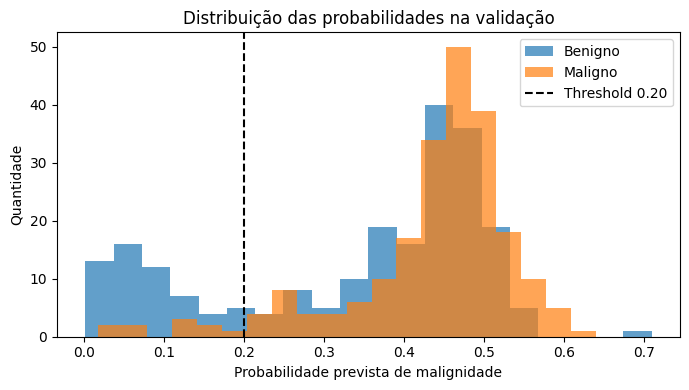

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step
              precision    recall  f1-score   support

     Benigno       0.69      0.13      0.21       276
     Maligno       0.52      0.94      0.67       276

    accuracy                           0.53       552
   macro avg       0.60      0.53      0.44       552
weighted avg       0.60      0.53      0.44       552



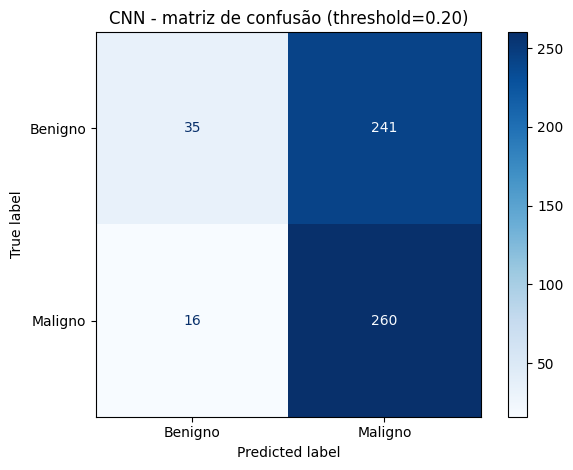

Observação: se as duas distribuições de probabilidade estiverem muito sobrepostas, o modelo ainda não aprendeu separação visual suficiente.


In [13]:
def predict_probabilities(dataset: tf.data.Dataset) -> np.ndarray:
    """Return model probabilities as a flat numpy array."""
    return model.predict(dataset).ravel()

val_probabilities = predict_probabilities(val_ds)
y_val = val_df['target'].to_numpy()

threshold_rows = []
for threshold in np.linspace(0.10, 0.90, 81):
    val_predictions = (val_probabilities >= threshold).astype(int)
    threshold_rows.append(
        {
            'threshold': threshold,
            'f1_maligno': f1_score(y_val, val_predictions, pos_label=1),
            'balanced_accuracy': balanced_accuracy_score(y_val, val_predictions),
            'predicted_positive_rate': val_predictions.mean(),
        }
    )

threshold_df = pd.DataFrame(threshold_rows).sort_values(
    ['f1_maligno', 'balanced_accuracy'], ascending=False
)
best_threshold = float(threshold_df.iloc[0]['threshold'])

print(f'Melhor threshold pela validação: {best_threshold:.2f}')
display(threshold_df.head(10))

plt.figure(figsize=(7, 4))
plt.hist(val_probabilities[y_val == 0], bins=20, alpha=0.7, label='Benigno')
plt.hist(val_probabilities[y_val == 1], bins=20, alpha=0.7, label='Maligno')
plt.axvline(best_threshold, color='black', linestyle='--', label=f'Threshold {best_threshold:.2f}')
plt.title('Distribuição das probabilidades na validação')
plt.xlabel('Probabilidade prevista de malignidade')
plt.ylabel('Quantidade')
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'cnn_validation_probability_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

test_probabilities = predict_probabilities(test_ds)
test_predictions = (test_probabilities >= best_threshold).astype(int)
y_test = test_df['target'].to_numpy()

print(classification_report(y_test, test_predictions, target_names=['Benigno', 'Maligno']))

cm = confusion_matrix(y_test, test_predictions, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Maligno'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'CNN - matriz de confusão (threshold={best_threshold:.2f})')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'cnn_confusion_matrix.png', dpi=160, bbox_inches='tight')
plt.show()

print('Observação: se as duas distribuições de probabilidade estiverem muito sobrepostas, o modelo ainda não aprendeu separação visual suficiente.')


## 8. Discussão crítica

- A versão atual monitora `val_auc`, escolhe o threshold com a validação e mostra a distribuição das probabilidades para revelar se o modelo realmente separa benignos e malignos.
- A CNN usa recortes para reduzir custo computacional, mas isso também limita o contexto anatômico da mamografia completa.
- O modo rápido favorece portabilidade e didática; não deve ser interpretado como modelo clínico pronto.
- Sinais de overfitting devem ser avaliados pelas curvas de treino e validação.
- Antes de qualquer uso real, seria necessario validar com bases externas, revisar erros com especialistas e garantir governanca clínica.
- O medico deve sempre ter a palavra final no diagnóstico.
